# Notebook 01: Análisis de calidad de los datos
## Fase CRISP-DM: Entendimiento y preparación de los datos

### 1. Configuración
El objetivo es identificar, documentar y corregir la calidad de los datos en el dataset de pacientes.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, os.path.abspath('..'))

from src import (
    AgeLimits,
    OutlierConfig,
    DataVersion,
    COLUMNS,
    TRANSFORMATION_DESCRIPTIONS,
    PATHS_PROJECT,
    standardize_dates,
    get_missing_values_report,
    remove_missing_values,
    remove_duplicates,
    filter_age,
    detect_multivariate_outliers,
    remove_multivariate_outliers,
    plot_combined_boxplots,
    plot_scatter_with_outliers,
    ensure_directory,
    save_clean_dataset,
    create_version_changes,
    save_version_changes,
    create_versioning_readme,
    print_multiple_unique_values,
    compare_mean_median,
    upload_csv_to_azure
)

#### 1.1 Estadísticos descriptivos

Se cargó el dataset original desde 'data/v1_raw/pacientes.csv'. A continuación se muestran los primeros registros y las estadísticas descriptivas de las variables.

In [4]:
df = pd.read_csv(DataVersion.RAW_PATH)
df.head(25)

,id_paciente,edad_paciente,sexo,peso_kg,altura_cm,fecha_registro,frecuencia_cardiaca_media_bpm,derivacion_ecg,frecuencia_muestreo_hz,etiqueta
0,P0305,82.0,M,69.8,168.0,2023-10-04,69.4,II,250,Normal
1,P0500,58.0,M,70.9,178.9,2023-04-23,79.2,II,250,Normal
2,P0442,49.0,M,84.2,173.1,2023-01-25,72.7,II,250,Normal
3,P0154,39.0,F,80.5,156.4,2023-06-24,87.0,II,250,Anormal
4,P0479,22.0,F,78.7,165.5,2023-01-28,77.8,II,250,Normal
5,P0132,34.0,M,75.5,170.9,27/01/2023,70.8,II,250,Normal
6,P0205,61.0,M,69.9,163.3,2023-06-29,89.1,II,250,Anormal
7,P0283,42.0,M,78.2,167.3,2023-11-02,64.1,II,250,Anormal
8,P0326,56.0,F,69.4,161.7,2023-02-21,74.2,II,250,Normal
9,P0248,26.0,F,67.3,169.5,2023-04-23,56.1,II,250,Normal


In [5]:
print(df.shape)

(515, 10)


In [6]:
df_describe = df.describe(include='all') 
df_describe

,id_paciente,edad_paciente,sexo,peso_kg,altura_cm,fecha_registro,frecuencia_cardiaca_media_bpm,derivacion_ecg,frecuencia_muestreo_hz,etiqueta
count,515,511.000000,511,509.000000,509.000000,515,515.000000,515,515.0,515
unique,500,NaN,2,NaN,NaN,294,NaN,1,NaN,2
top,P0422,NaN,M,NaN,NaN,2023-09-19,NaN,II,NaN,Normal
freq,2,NaN,261,NaN,NaN,7,NaN,515,NaN,310
mean,NaN,54.671233,NaN,72.233595,166.812377,NaN,80.997282,NaN,250.0,NaN
std,NaN,18.012891,NaN,11.579113,8.620153,NaN,17.229858,NaN,0.0,NaN
min,NaN,-5.000000,NaN,33.500000,143.800000,NaN,44.300000,NaN,250.0,NaN
25%,NaN,43.000000,NaN,64.600000,160.600000,NaN,68.050000,NaN,250.0,NaN
50%,NaN,56.000000,NaN,72.200000,166.200000,NaN,77.000000,NaN,250.0,NaN
75%,NaN,65.000000,NaN,80.300000,173.100000,NaN,90.850000,NaN,250.0,NaN


In [7]:
print(df[COLUMNS['label']].value_counts())
print(df[COLUMNS['label']].value_counts(normalize=True) * 100)

etiqueta
Normal     310
Anormal    205
Name: count, dtype: int64
etiqueta
Normal     60.194175
Anormal    39.805825
Name: proportion, dtype: float64


Se identificaron valores faltantes en las columnas de edad (4 registros), sexo (4 registros), peso (6 registros) y altura (6 registros), que en total representan menos de un 4% del total de 515 registros. Se detectaron valores imposibles de edad, incluyendo edades negativas y edades mayores a 120 años, lo que sugiere errores de entrada de datos. También se detectan registros duplicados en el identificador de paciente. La variable 'fecha_registro' presentó formatos inconsistentes. Finalmente, la variable 'etiqueta' presenta un desbalance dado que la etiqueta "Normal" representa un 60.2% de los datos, un factor que deberá considerarse en la selección de métricas del modelo.

#### 1.2 Dimensión de calidad de los datos

##### 1.2.1 Completitud

La completitud evalúa la presencia de valores faltantes en el dataset. Se identificaron columnas con valores nulos y se cuantificó su impacto.

In [8]:
missing_report = get_missing_values_report(df)
print(missing_report)

na_totales = missing_report['Missing_Count'].sum()
print(f"\nCantidad total de valores nulos: {na_totales}")

          Column  Missing_Count  Percentage
1  edad_paciente              4    0.776699
2           sexo              4    0.776699
3        peso_kg              6    1.165049
4      altura_cm              6    1.165049

Cantidad total de valores nulos: 20


In [9]:
initial_registers = len(df)
print(f"Registros iniciales: {initial_registers}")

df = remove_missing_values(df)

registers = len(df)
deleted_registers = initial_registers - registers
print(f"Registros después de eliminar nulos: {registers}")
print(f"Registros eliminados: {deleted_registers}")
print(f"Porcentaje eliminado: {(deleted_registers / initial_registers) * 100:.2f}%")

print("\nVerificación de nulos:")
print(df.isnull().sum())

Registros iniciales: 515
Registros después de eliminar nulos: 495
Registros eliminados: 20
Porcentaje eliminado: 3.88%

Verificación de nulos:
id_paciente                      0
edad_paciente                    0
sexo                             0
peso_kg                          0
altura_cm                        0
fecha_registro                   0
frecuencia_cardiaca_media_bpm    0
derivacion_ecg                   0
frecuencia_muestreo_hz           0
etiqueta                         0
dtype: int64


Se decidió eliminar los registros con valores nulos en cualquier variable, debido a que los faltantes representaban menos del 4% del total de datos. Esto se justifica porque el porcentaje es lo suficientemente bajo para no afectar significativamente el tamaño de la muestra y evita suposiciones que podrían sesgar el análisis.

##### 1.2.2 Consistencia

La evaluación de consistencia tiene como objetivo detectar valores que no cumplen con los formatos, rangos o relaciones lógicas esperadas.

In [10]:
columns_to_inspect = [
    (COLUMNS['age'], 'Edad'),
    (COLUMNS['sex'], 'Sexo'),
    (COLUMNS['date'], 'Fecha de registro'),
    (COLUMNS['heart_rate'], 'Frecuencia cardíaca media'),
    (COLUMNS['ecg_lead'], 'Derivación ECG'),
    (COLUMNS['sampling_rate'], 'Frecuencia de muestreo'),
    (COLUMNS['label'], 'Etiqueta')
]

print_multiple_unique_values(df, columns_to_inspect)

Edad unique values: [ 82.  58.  49.  39.  22.  34.  61.  42.  56.  26.  54.  43.  65.  45.
  59.  75.  47.  74.  51. 150.  44.  25.  38.  40.  64.  81.  46.  55.
  28.  63.  31.  69.  32.  76.  73.  30.  53.  50.  85.  91.  62.  52.
  48.  60.  72.  68.  24.  66.  83.  89.  37.  19.  18.  36.  87.  71.
  20.  41.  27.  70.  67.  77.  57.  29.  35.  86. 132.  -3.  23.  -1.
  90.  79.  33.  80.  78.  -5.  93.]
Number of unique values: 77
----------------------------------------
Sexo unique values: ['M' 'F']
Number of unique values: 2
----------------------------------------
Fecha de registro unique values: ['2023-10-04' '2023-04-23' '2023-01-25' '2023-06-24' '2023-01-28'
 '27/01/2023' '2023-06-29' '2023-11-02' '2023-02-21' '2023-05-22'
 '2023-06-04' '19/07/2023' '2023-01-07' '2023-09-03' '2023-09-16'
 '2023-07-04' '2023-08-13' '2023-05-28' '2023-02-20' '2023-07-21'
 '2023-06-26' '2023-06-21' '2023-11-04' '2023-11-23' '2023-03-23'
 '2023-08-29' '20/02/2023' 'July 26, 2023' 'August 12, 202

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 495 entries, 0 to 514
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id_paciente                    495 non-null    object 
 1   edad_paciente                  495 non-null    float64
 2   sexo                           495 non-null    object 
 3   peso_kg                        495 non-null    float64
 4   altura_cm                      495 non-null    float64
 5   fecha_registro                 495 non-null    object 
 6   frecuencia_cardiaca_media_bpm  495 non-null    float64
 7   derivacion_ecg                 495 non-null    object 
 8   frecuencia_muestreo_hz         495 non-null    int64  
 9   etiqueta                       495 non-null    object 
dtypes: float64(4), int64(1), object(5)
memory usage: 42.5+ KB


Además de las edades negativas y mayores a 120 que se habían logrado detectar anteriormente, así como los diferentes formatos de fecha, se pudo observar que los valores para el sexo no contienen datos inconsistentes, además los formatos de los campos son los esperados según su descripción.

In [12]:
df = standardize_dates(df, COLUMNS['date'])
print(f"Rango de fechas: {df[COLUMNS['date']].min()} a {df[COLUMNS['date']].max()}")

Rango de fechas: 2023-01-01 00:00:00 a 2023-11-26 00:00:00


In [13]:
df = filter_age(df, COLUMNS['age'])
print(f"Registros después de filtrar edades ({AgeLimits.MIN}-{AgeLimits.MAX}): {len(df)}")
print(f"Edad mínima: {df[COLUMNS['age']].min()}")
print(f"Edad máxima: {df[COLUMNS['age']].max()}")

Registros después de filtrar edades (0-120): 490
Edad mínima: 18.0
Edad máxima: 93.0


##### 1.2.3 Duplicidad

Se verificó la presencia de registros duplicados en el dataset, especialmente en el identificador de paciente, que debe ser único.

In [14]:
duplicated_rows = df.duplicated()
number_of_duplicated_rows = duplicated_rows.sum()
print("Número de filas duplicadas: ", number_of_duplicated_rows)

Número de filas duplicadas:  1


In [15]:
df = remove_duplicates(df, subset=[COLUMNS['patient_id']])
print(f"Duplicados después de limpieza: {df.duplicated().sum()}")

Duplicados después de limpieza: 0


##### 1.2.4 Integridad

Esta sección tiene como objetivo verificar la relación entre los diferentes datos, asegurando que cada paciente en el dataset "pacientes" tenga su correspondiente archivo de señal ECG. Esto es fundamental para que no haya información faltante.

In [16]:
patients_ids = set(df[COLUMNS['patient_id']])

path_signals = PATHS_PROJECT['signals']
files = os.listdir(path_signals)
signals_ids = set([f.replace('.csv', '') for f in files if f.endswith('.csv')])

patients_without_signal = patients_ids - signals_ids

print(f"Total pacientes: {len(patients_ids)}")
print(f"Archivos de señal: {len(signals_ids)}")
print(f"Pacientes sin señal: {len(patients_without_signal)}")

if len(patients_without_signal) > 0:
    print(f"Ejemplos: {list(patients_without_signal)[:5]}")

Total pacientes: 476
Archivos de señal: 501
Pacientes sin señal: 0


### 2. Preparación de los datos

#### 2.1 Detección de outliers

La detección de outliers se abordó en dos etapas con el fin de identificar tanto valores atípicos univariados como combinaciones anómalas entre variables.

Se generaron boxplots para cada variable numérica (edad_paciente, peso_kg, altura_cm, frecuencia_cardiaca_media_bpm) con el objetivo de identificar visualmente la presencia de valores extremos y evaluar el sesgo de la distribución de los datos.

Para identificar outliers que consideran la relación entre múltiples variables, se calculó la distancia de Mahalanobis para cada registro, utilizando las variables edad_paciente y peso_kg. Esta distancia mide qué tan lejos se encuentra un punto del centro de la distribución, teniendo en cuenta la covarianza de los datos. Los valores atípicos se determinaron comparando la distancia calculada con el cuantil 0.995 de la distribución chi-cuadrado. Los registros con distancia superior a este umbral son clasificados como outliers y eliminados del dataset.

In [17]:
columns_to_compare = [
    COLUMNS['age'],
    COLUMNS['weight'],
    COLUMNS['height'],
    COLUMNS['heart_rate']
]

comparison_df = compare_mean_median(df, columns_to_compare)
print(comparison_df.to_string(index=False))

                     Variable  Media  Mediana  Diferencia
                edad_paciente  54.45    56.00       -1.55
                      peso_kg  72.28    72.20        0.08
                    altura_cm 166.87   166.15        0.72
frecuencia_cardiaca_media_bpm  80.97    77.00        3.97


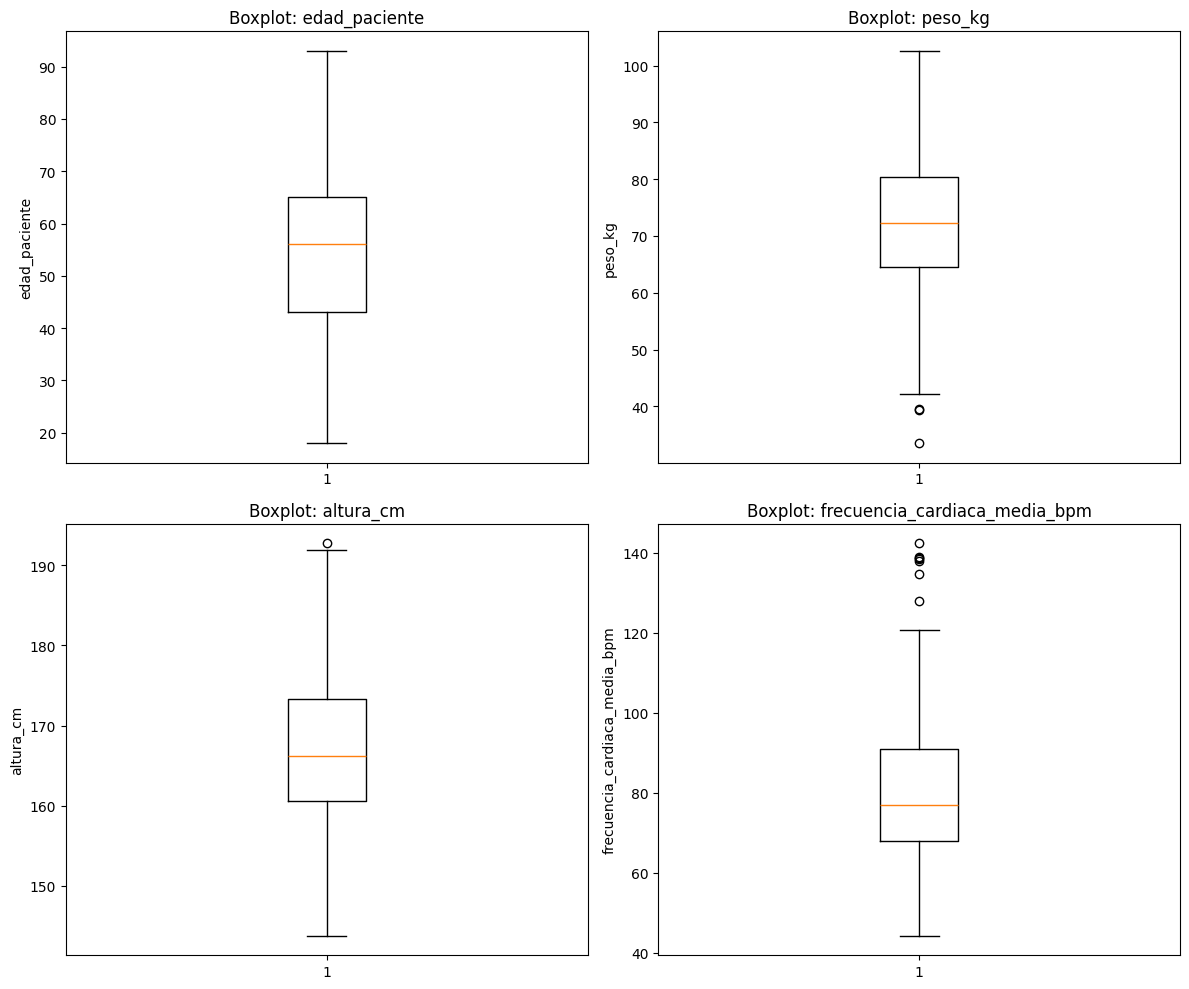

In [18]:
outlier_columns = [
    COLUMNS['age'],
    COLUMNS['weight'],
    COLUMNS['height'],
    COLUMNS['heart_rate']
]

fig = plot_combined_boxplots(df, outlier_columns)
plt.show()

La diferencia entre la media y la mediana no es significativa para ninguna variable, esta nos podría haber dado indicios sobre sesgos en las distribuciones de los datos. Por otro lado, los boxplot nos muestran especial atención en la frecuencia cardiaca pero estos no fueron eliminados ya que pueden ser hallazgos clínicamente relevantes y no errores de medición, en un caso productivo estos valores los validaría con el equipo antes de tomar cualquier decisión. Por otro lado, el peso parece tener valores atípicos relativamente altos pero se hará una detección más robusta ya que esta variable puede depender de otras como la edad.

In [19]:
df_with_outliers, outlier_mask = detect_multivariate_outliers(
    df,
    [COLUMNS['age'], COLUMNS['weight']],
    quantile=OutlierConfig.QUANTILE
)

print(f"Outliers detectados: {outlier_mask.sum()} de {len(df)} registros")

Outliers detectados: 1 de 476 registros


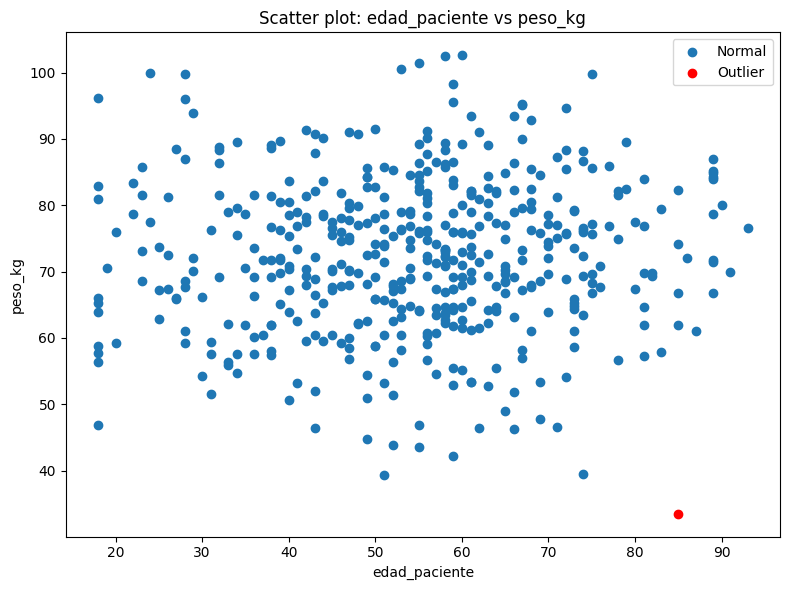

In [20]:
fig = plot_scatter_with_outliers(
    df,
    COLUMNS['age'],
    COLUMNS['weight'],
    outlier_mask
)
plt.show()

In [21]:
df_clean = remove_multivariate_outliers(
    df,
    [COLUMNS['age'], COLUMNS['weight']],
    quantile=OutlierConfig.QUANTILE
)

print(f"Registros después de eliminar outliers: {len(df_clean)}")
print(df_clean.shape)

Registros después de eliminar outliers: 475
(475, 10)


### 3. Versionamiento de datos

In [22]:
ensure_directory(DataVersion.CLEAN_DIR)

clean_metadata = {
    'version': '2.0',
    'name': 'Clean Patient Dataset',
    'records': len(df_clean),
    'columns': list(df_clean.columns),
    'target_distribution': df_clean[COLUMNS['label']].value_counts().to_dict(),
    'target_percentages': (df_clean[COLUMNS['label']].value_counts(normalize=True) * 100).to_dict()
}

save_clean_dataset(df_clean, DataVersion.CLEAN_FILE, clean_metadata)

transformations = [
    TRANSFORMATION_DESCRIPTIONS['missing_values'],
    TRANSFORMATION_DESCRIPTIONS['invalid_ages'],
    TRANSFORMATION_DESCRIPTIONS['duplicates'],
    TRANSFORMATION_DESCRIPTIONS['date_standardization'],
    {
        **TRANSFORMATION_DESCRIPTIONS['outlier_removal'],
        'description': (
            f"Removed {DataVersion.ORIGINAL_RECORDS - len(df_clean)} multivariate "
            f"outliers using Mahalanobis distance (cutoff={OutlierConfig.QUANTILE})"
        )
    }
]

changes = create_version_changes(
    DataVersion.ORIGINAL_RECORDS,
    len(df_clean),
    transformations
)

save_version_changes(changes, PATHS_PROJECT['v2'])

versions_info = {'clean_records': len(df_clean)}
create_versioning_readme(PATHS_PROJECT['readme'], versions_info)

print("\nVersioning complete.")


Versioning complete.


In [23]:
df = df_clean.copy()
print(f"Dataset listo para el siguiente notebook: {len(df)} registros")
print(f"Columnas: {list(df.columns)}")

Dataset listo para el siguiente notebook: 475 registros
Columnas: ['id_paciente', 'edad_paciente', 'sexo', 'peso_kg', 'altura_cm', 'fecha_registro', 'frecuencia_cardiaca_media_bpm', 'derivacion_ecg', 'frecuencia_muestreo_hz', 'etiqueta']


### 4. Subir a la nube

In [24]:
from src.constants import connection_string

try:
    connection_string = os.environ['AZURE_CONNECTION_STRING']
    
    upload_csv_to_azure(
        df_clean,
        connection_string,
        'salva-health-data',
        'pacientes_clean.csv'
    )
    print("Dataset limpio subido a Azure Storage exitosamente")
    
except Exception as e:
    print(f"Error al subir el dataset a Azure: {e}")

File uploaded to Azure: salva-health-data/pacientes_clean.csv
Dataset limpio subido a Azure Storage exitosamente
